# Analyse du comportement utilisateur et de la conversion e-commerce

## Technologies utilisées

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## Objectifs

Cette étude vise à analyser le comportement des utilisateurs sur une plateforme e-commerce afin d'identifier les principaux leviers d'amélioration du taux de conversion.

Questions étudiées :

- Comment se répartissent les événements ?
- Quels produits performent le mieux ?
- Quelles catégories convertissent le mieux ?
- Quels profils utilisateurs sont les plus engagés ?
- Quel est l'impact du prix sur les achats ?

## Chargement des librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)

## Chargement des données

In [2]:
files = [
    "2019-Oct.csv",
    "2019-Nov.csv",
    "2019-Dec.csv",
    "2020-Jan.csv",
    "2020-Feb.csv",
    "2020-Mar.csv",
    "2020-Apr.csv"
]

dataframes = []

for file in files:
    df = pd.read_csv(file, nrows=100000)
    dataframes.append(df)

df_all = pd.concat(dataframes, ignore_index=True)

df_all.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


## Compréhension et Analyse des données

In [3]:
print(df_all.shape)

(700000, 9)


In [4]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     700000 non-null  object 
 1   event_type     700000 non-null  object 
 2   product_id     700000 non-null  int64  
 3   category_id    700000 non-null  int64  
 4   category_code  581314 non-null  object 
 5   brand          598702 non-null  object 
 6   price          700000 non-null  float64
 7   user_id        700000 non-null  int64  
 8   user_session   700000 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 48.1+ MB


In [5]:
df_all.isnull().sum()

event_time            0
event_type            0
product_id            0
category_id           0
category_code    118686
brand            101298
price                 0
user_id               0
user_session          0
dtype: int64

In [6]:
df_all["category_code"] = df_all["category_code"].fillna("unknown")
df_all["brand"] = df_all["brand"].fillna("unknown")

In [7]:
## Feature engineering
df_all["event_time"] = pd.to_datetime(df_all["event_time"])
df_all["month"] = df_all["event_time"].dt.month

In [8]:
## Analyse globale du comportement
funnel = df_all["event_type"].value_counts()
funnel

event_type
view        668576
cart         23318
purchase      8106
Name: count, dtype: int64

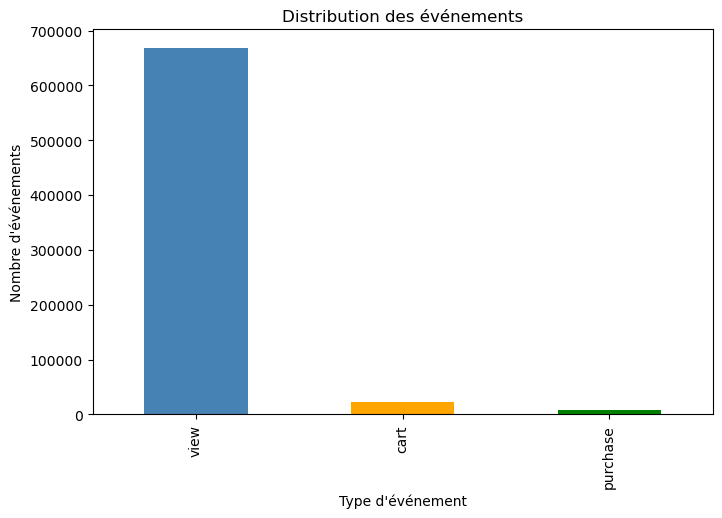

In [9]:
plt.figure(figsize=(8,5))

funnel.plot(
    kind="bar",
    color=["steelblue", "orange", "green"]
)

plt.title("Distribution des événements")
plt.xlabel("Type d'événement")
plt.ylabel("Nombre d'événements")

plt.show()

## ANALYSE PRODUIT

In [10]:
### Construction du funnel produit
product_funnel = df_all.groupby(["product_id", "event_type"]).size().unstack(fill_value=0)
product_funnel.head()

event_type,cart,purchase,view
product_id,,,
1000978,0,0,8
1001588,0,0,39
1001605,3,0,22
1001606,2,0,0
1001618,0,0,9


In [11]:
### Calcul du taux de conversion par produit
product_funnel["conversion_rate"] = product_funnel["purchase"] / product_funnel["view"]

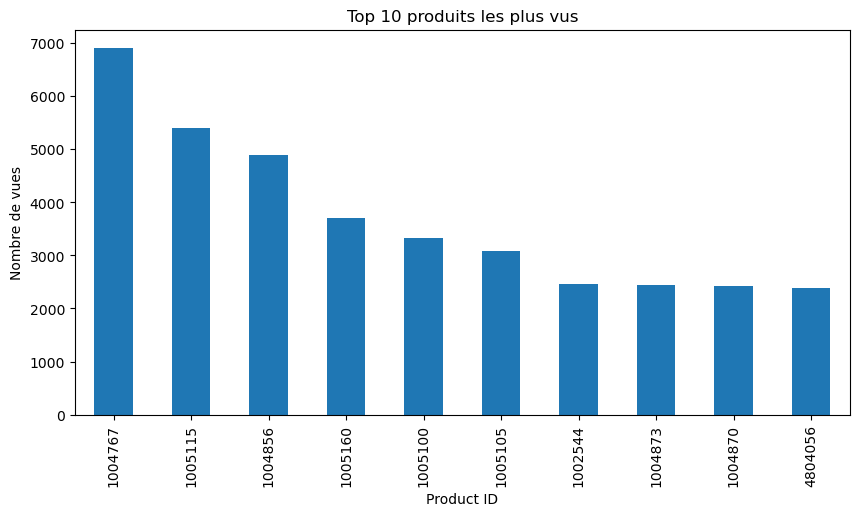

In [12]:
## TOP 10 DES PRODUITS LES PLUS VUS
top_views = product_funnel.sort_values("view", ascending=False).head(10)

top_views["view"].plot(kind="bar", figsize=(10,5))
plt.title("Top 10 produits les plus vus")
plt.xlabel("Product ID")
plt.ylabel("Nombre de vues")
plt.show()

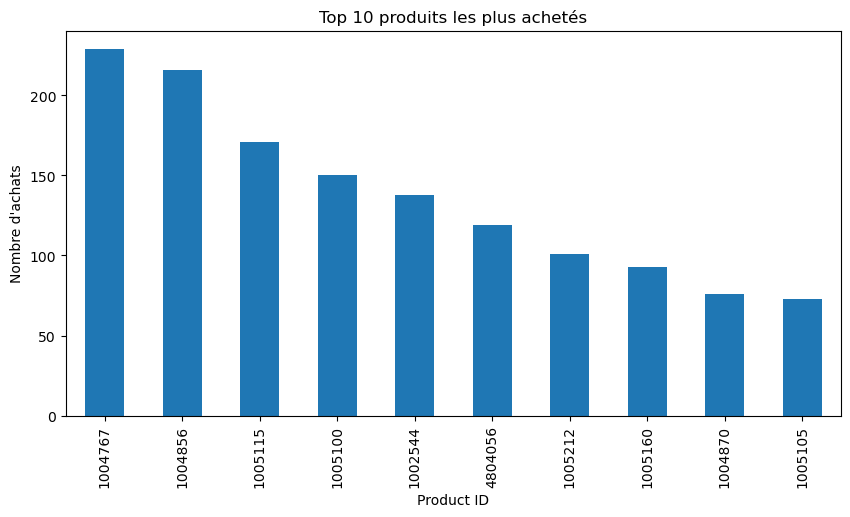

In [13]:
## Top produits les plus achetés
top_purchases = product_funnel.sort_values("purchase", ascending=False).head(10)

top_purchases["purchase"].plot(kind="bar", figsize=(10,5))
plt.title("Top 10 produits les plus achetés")
plt.xlabel("Product ID")
plt.ylabel("Nombre d'achats")
plt.show()

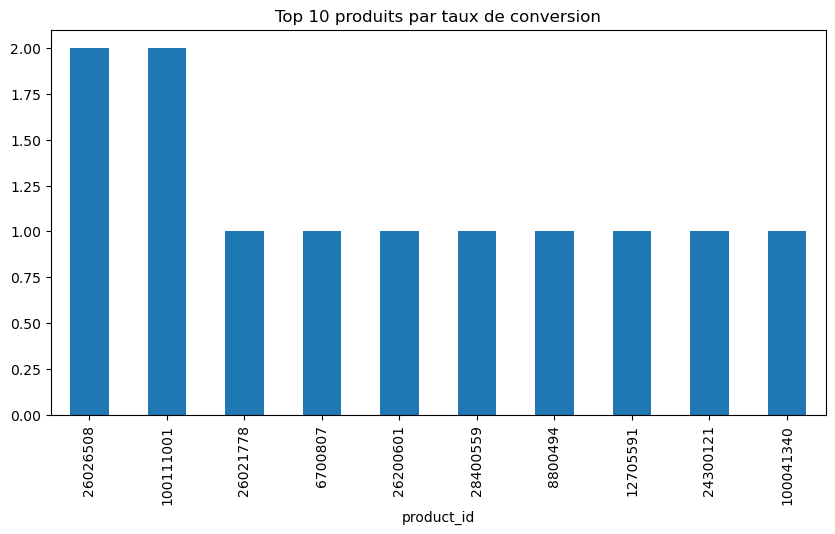

In [14]:
## Top produits par conversion
product_funnel_clean = product_funnel[product_funnel["view"] > 0]

top_conversion = product_funnel_clean.sort_values(
    "conversion_rate",
    ascending=False
).head(10)

top_conversion["conversion_rate"].plot(kind="bar", figsize=(10,5))
plt.title("Top 10 produits par taux de conversion")
plt.show()

## ANALYSE CATÉGORIE

In [15]:
### Construction du funnel par catégorie
category_funnel = df_all.groupby(["category_code", "event_type"]).size().unstack(fill_value=0)
category_funnel.head()

event_type,cart,purchase,view
category_code,,,
accessories.bag,131,35,6574
accessories.umbrella,4,1,675
accessories.wallet,48,8,2152
apparel.belt,0,0,29
apparel.costume,144,31,3850


In [16]:
### Calcul du taux de conversion par catégorie
category_funnel["conversion_rate"] = (
    category_funnel["purchase"] / category_funnel["view"]
)

In [17]:
### Filtrage des catégories sans consultation
category_funnel = category_funnel[category_funnel["view"] > 0]

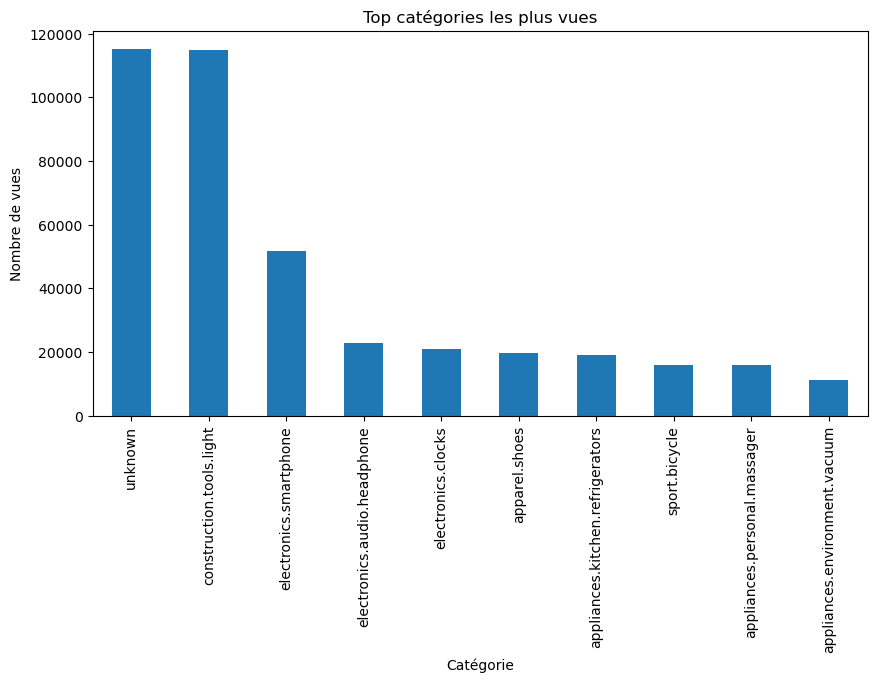

In [18]:
## TOP catégories (VUES)
top_views = category_funnel.sort_values("view", ascending=False).head(10)

top_views["view"].plot(kind="bar", figsize=(10,5))
plt.title("Top catégories les plus vues")
plt.xlabel("Catégorie")
plt.ylabel("Nombre de vues")
plt.show()

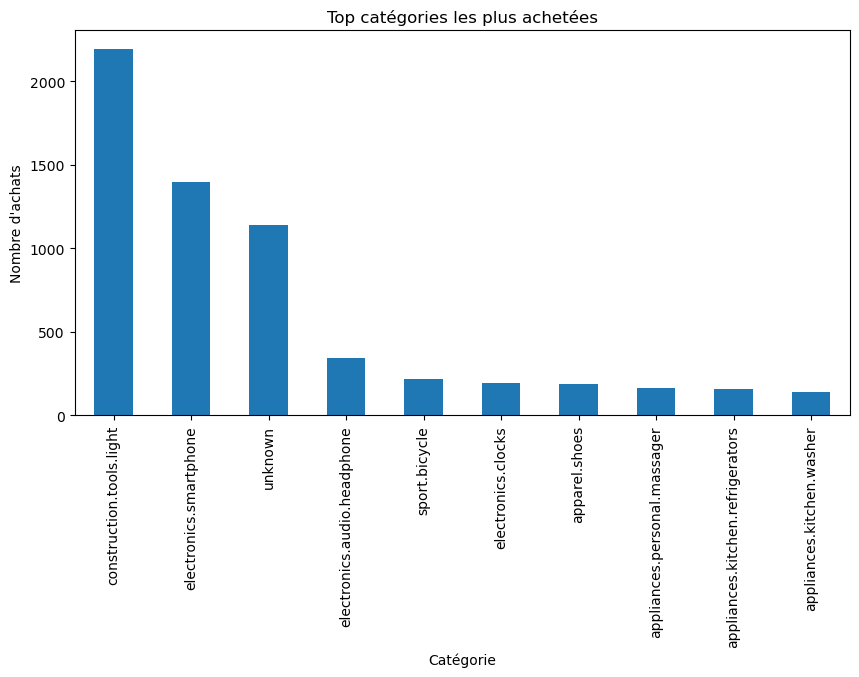

In [19]:
## TOP catégories (ACHATS)
top_purchases = category_funnel.sort_values("purchase", ascending=False).head(10)

top_purchases["purchase"].plot(kind="bar", figsize=(10,5))
plt.title("Top catégories les plus achetées")
plt.xlabel("Catégorie")
plt.ylabel("Nombre d'achats")
plt.show()

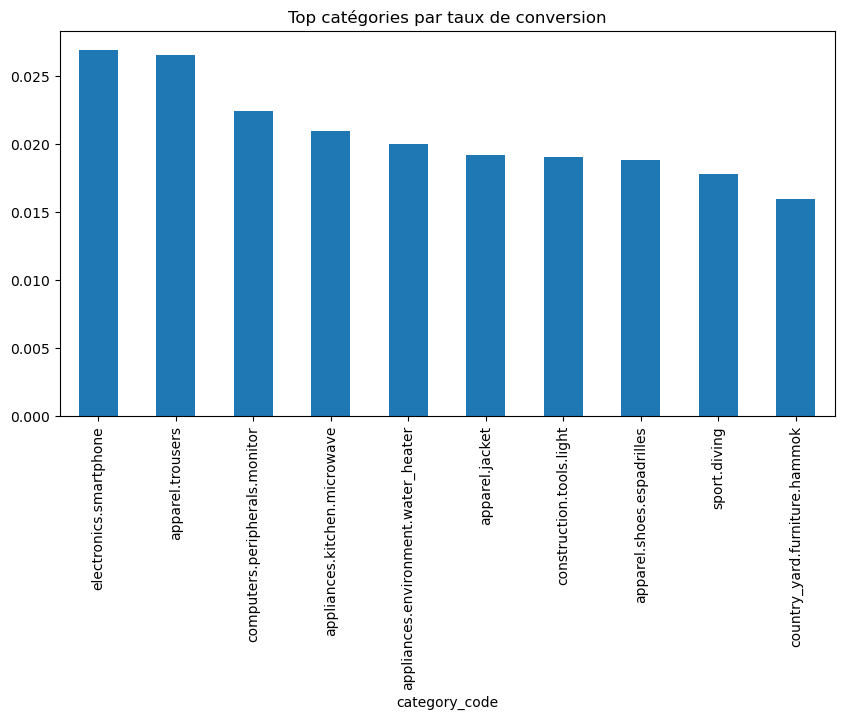

In [20]:
### Top catégories par taux de conversion
top_conversion = category_funnel.sort_values(
    "conversion_rate",
    ascending=False
).head(10)

top_conversion["conversion_rate"].plot(kind="bar", figsize=(10,5))
plt.title("Top catégories par taux de conversion")
plt.show()

In [21]:
### Classement combiné des catégories
top_combined = category_funnel.sort_values(
    ["purchase", "conversion_rate"],
    ascending=False
).head(10)

top_combined

event_type,cart,purchase,view,conversion_rate
category_code,,,,
construction.tools.light,7540,2195,114866,0.019109
electronics.smartphone,1650,1396,51767,0.026967
unknown,2464,1139,115083,0.009897
electronics.audio.headphone,850,346,22874,0.015126
sport.bicycle,988,216,15997,0.013503
electronics.clocks,653,194,20974,0.009250
apparel.shoes,792,189,19633,0.009627
appliances.personal.massager,644,165,15889,0.010385
appliances.kitchen.refrigerators,519,155,19038,0.008142


#### Ce classement met en évidence les catégories les plus stratégiques, car elles combinent un volume d’achats élevé et une bonne capacité à convertir les consultations en achats.

## ANALYSE UTILISATEUR

In [22]:
df_all.groupby("user_id").size().describe()

count    138207.000000
mean          5.064866
std           8.314265
min           1.000000
25%           1.000000
50%           2.000000
75%           6.000000
max         275.000000
dtype: float64

In [23]:
## utilisateurs les plus actifs
top_users = df_all.groupby("user_id").size().sort_values(ascending=False).head(10)
top_users

user_id
608826081    275
608823551    273
608833906    271
608836416    271
608831365    270
608839250    270
608828620    270
516254329    268
608842218    266
608845072    265
dtype: int64

In [24]:
### Répartition des actions par utilisateur
user_activity = df_all.pivot_table(
    index="user_id",
    columns="event_type",
    aggfunc="size",
    fill_value=0
)

user_activity.head()

event_type,cart,purchase,view
user_id,,,
100705743,0,0,10
104397540,0,0,7
120701478,0,0,1
158971609,0,0,1
215817632,0,0,1


In [25]:
## utilisateurs qui achètent vraiment
buyers = user_activity[user_activity["purchase"] > 0]
buyers.describe()

event_type,cart,purchase,view
count,6360.000000,6360.000000,6360.000000
mean,1.344025,1.274528,6.901572
std,2.184495,0.868874,9.956679
min,0.000000,1.000000,0.000000
25%,0.000000,1.000000,2.000000
50%,1.000000,1.000000,4.000000
75%,2.000000,1.000000,8.000000
max,58.000000,26.000000,179.000000


In [26]:
## utilisateurs “actifs mais sans achat”
no_purchase_users = user_activity[user_activity["purchase"] == 0]
no_purchase_users.describe()

event_type,cart,purchase,view
count,131847.000000,131847.0,131847.000000
mean,0.112024,0.0,4.737931
std,0.685830,0.0,8.006420
min,0.000000,0.0,0.000000
25%,0.000000,0.0,1.000000
50%,0.000000,0.0,2.000000
75%,0.000000,0.0,5.000000
max,42.000000,0.0,275.000000


In [27]:
user_activity_clean = user_activity[
    user_activity["view"] > 0
]

In [28]:
## taux de conversion par utilisateur
user_activity_clean["conversion_rate"] = (
    user_activity_clean["purchase"]
    /
    user_activity_clean["view"]
)

In [29]:
user_activity_clean["conversion_rate"].describe()

count    137492.000000
mean          0.015990
std           0.102433
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           8.000000
Name: conversion_rate, dtype: float64

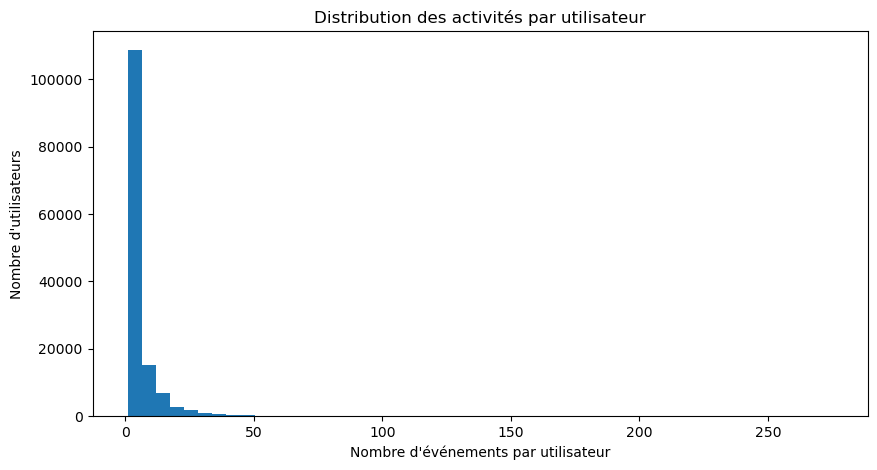

In [30]:
## VISUALISATION de la  distribution des activités
df_all.groupby("user_id").size().plot(kind="hist", bins=50, figsize=(10,5))
plt.title("Distribution des activités par utilisateur")
plt.xlabel("Nombre d'événements par utilisateur")
plt.ylabel("Nombre d'utilisateurs")
plt.show()

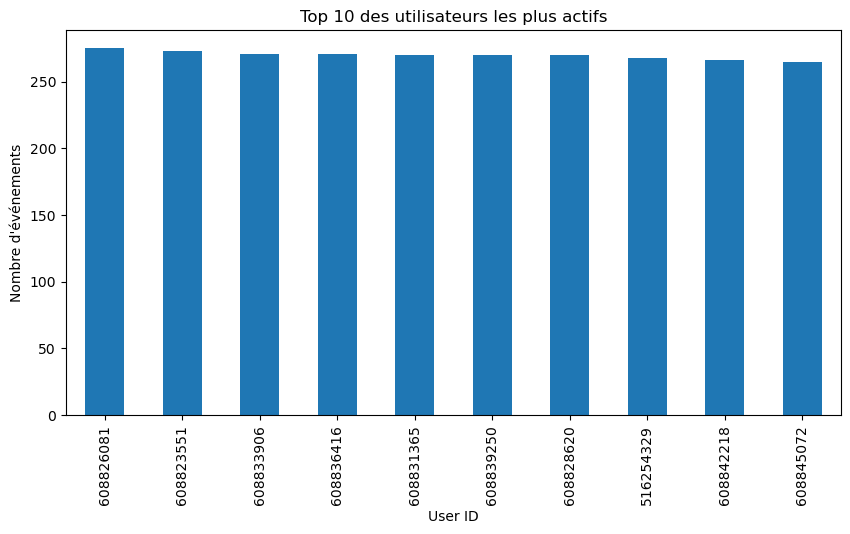

In [31]:
### Top 10 des utilisateurs les plus actifs
df_all.groupby("user_id").size().sort_values(ascending=False).head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 des utilisateurs les plus actifs")
plt.xlabel("User ID")
plt.ylabel("Nombre d'événements")
plt.show()

## ANALYSE PRIX

In [32]:
df_all.groupby("event_type")["price"].mean()

event_type
cart        271.857866
purchase    285.787277
view        285.474540
Name: price, dtype: float64

In [33]:
df_all["price"].describe()

count    700000.000000
mean        285.024571
std         356.453623
min           0.000000
25%          62.040000
50%         163.970000
75%         347.500000
max        2574.070000
Name: price, dtype: float64

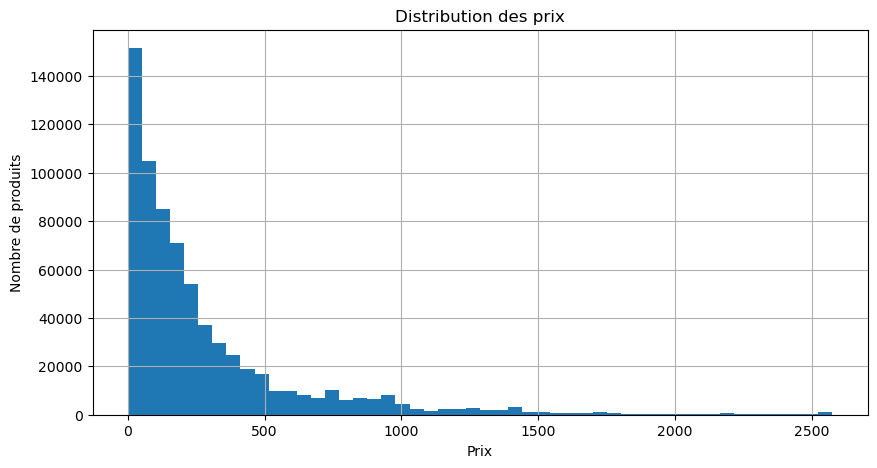

In [34]:
plt.figure(figsize=(10,5))

df_all["price"].hist(bins=50)

plt.title("Distribution des prix")
plt.xlabel("Prix")
plt.ylabel("Nombre de produits")

plt.show()

In [35]:
### Analyse des prix des produits achetés
df_all[df_all["event_type"] == "purchase"]["price"].describe()

count    8106.000000
mean      285.787277
std       321.517838
min         0.790000
25%        81.372500
50%       175.830000
75%       346.790000
max      2573.790000
Name: price, dtype: float64

In [36]:
df_all[df_all["event_type"] == "view"]["price"].describe()

count    668576.000000
mean        285.474540
std         358.100382
min           0.000000
25%          61.780000
50%         163.160000
75%         348.530000
max        2574.070000
Name: price, dtype: float64

In [37]:
## Prix moyen par categorie
df_all.groupby("category_code")["price"].mean().sort_values(ascending=False).head(10)

category_code
computers.notebook                  714.265385
accessories.umbrella                579.752676
apparel.shorts                      573.749463
furniture.living_room.sofa          567.506224
electronics.audio.headphone         525.367228
appliances.kitchen.refrigerators    499.161058
electronics.smartphone              463.220273
appliances.kitchen.dishwasher       452.729847
construction.tools.light            431.572459
appliances.personal.massager        377.341322
Name: price, dtype: float64

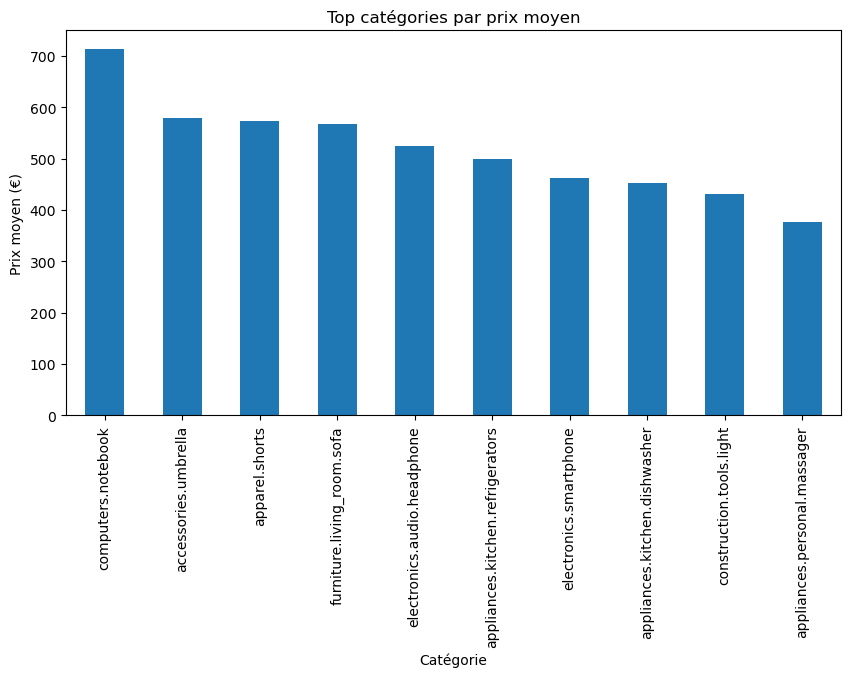

In [38]:
top_price_categories = (
    df_all.groupby("category_code")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_price_categories.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top catégories par prix moyen")
plt.xlabel("Catégorie")
plt.ylabel("Prix moyen (€)")
plt.show()

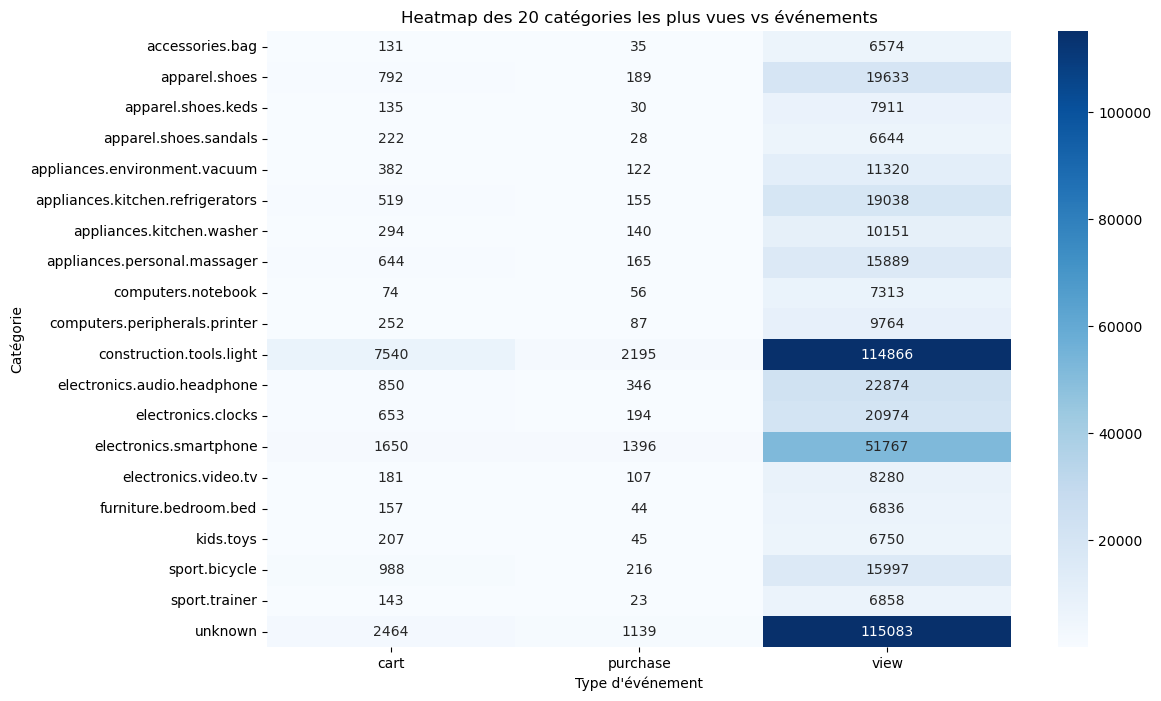

In [39]:
# Sélection des 20 catégories les plus vues
top_categories = (
    df_all[df_all["event_type"] == "view"]["category_code"]
    .value_counts()
    .head(20)
    .index
)

# Filtrer le dataset sur ces catégories
df_top_categories = df_all[df_all["category_code"].isin(top_categories)]

# Création de la heatmap
heatmap_data = df_top_categories.pivot_table(
    index="category_code",
    columns="event_type",
    values="user_id",
    aggfunc="count",
    fill_value=0
)

plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data, cmap="Blues", annot=True, fmt="d")

plt.title("Heatmap des 20 catégories les plus vues vs événements")
plt.xlabel("Type d'événement")
plt.ylabel("Catégorie")
plt.show()

#### La heatmap est limitée aux 20 catégories les plus vues afin d'améliorer la lisibilité. Elle permet de comparer les volumes de consultations, d'ajouts au panier et d'achats pour les catégories les plus représentatives.

In [40]:
## SEGMENTATION UTILISATEUR
user_activity = df_all.groupby("user_id").size()

segments = pd.cut(
    user_activity,
    bins=[0, 5, 20, 1000],
    labels=["low", "medium", "high"]
)

segments.value_counts()

low       103222
medium     29583
high        5402
Name: count, dtype: int64

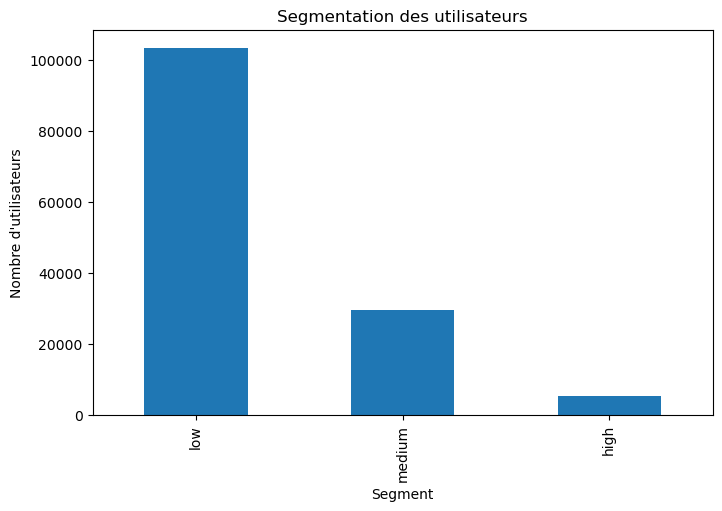

In [41]:
segments.value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Segmentation des utilisateurs")
plt.xlabel("Segment")
plt.ylabel("Nombre d'utilisateurs")

plt.show()

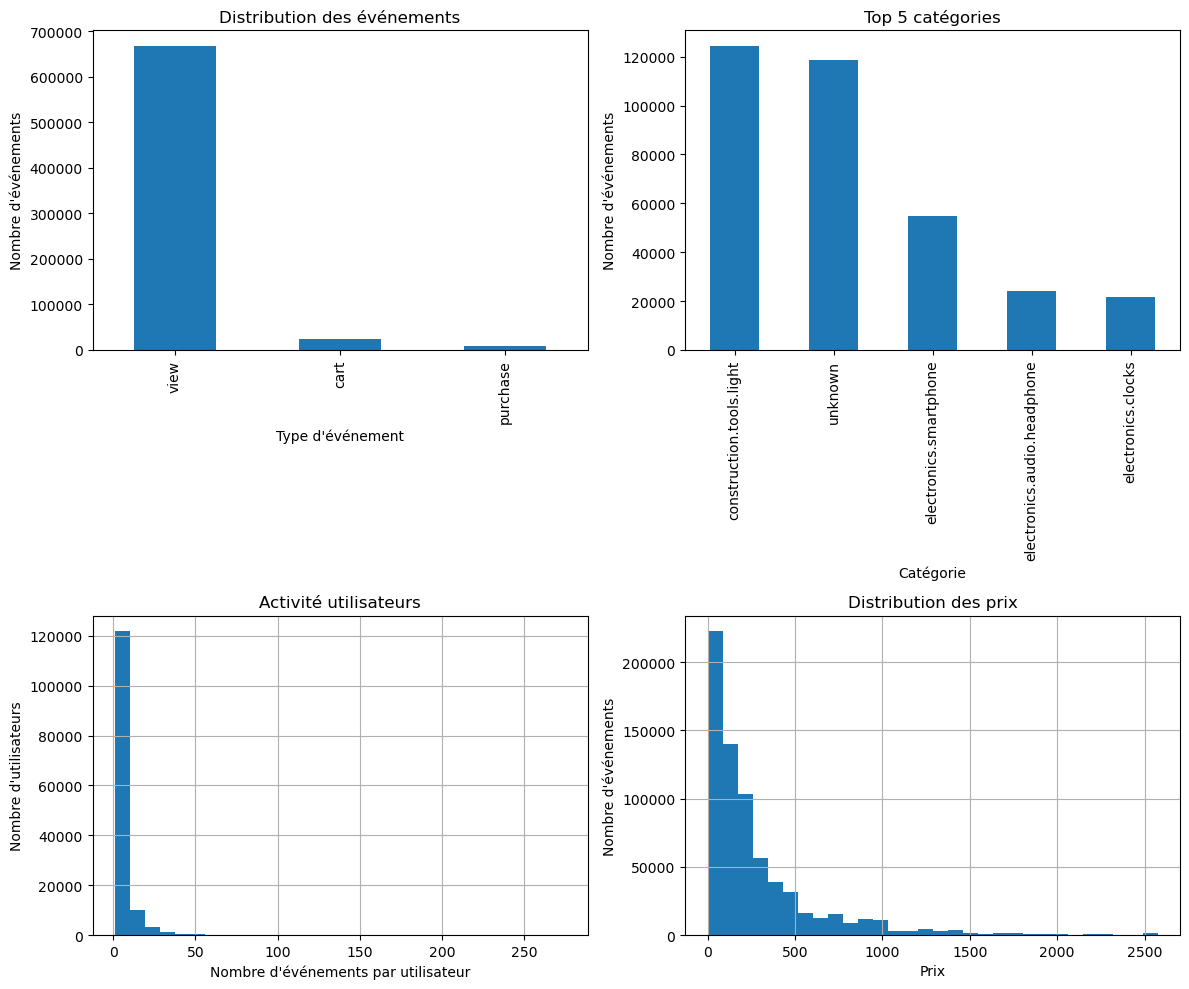

In [42]:
## Dashboard final
fig, axes = plt.subplots(2, 2, figsize=(12,10))

df_all["event_type"].value_counts().plot(kind="bar", ax=axes[0,0])
axes[0,0].set_title("Distribution des événements")
axes[0,0].set_xlabel("Type d'événement")
axes[0,0].set_ylabel("Nombre d'événements")

df_all.groupby("category_code").size().sort_values(ascending=False).head(5).plot(
    kind="bar",
    ax=axes[0,1]
)
axes[0,1].set_title("Top 5 catégories")
axes[0,1].set_xlabel("Catégorie")
axes[0,1].set_ylabel("Nombre d'événements")

df_all.groupby("user_id").size().hist(ax=axes[1,0], bins=30)
axes[1,0].set_title("Activité utilisateurs")
axes[1,0].set_xlabel("Nombre d'événements par utilisateur")
axes[1,0].set_ylabel("Nombre d'utilisateurs")

df_all["price"].hist(bins=30, ax=axes[1,1])
axes[1,1].set_title("Distribution des prix")
axes[1,1].set_xlabel("Prix")
axes[1,1].set_ylabel("Nombre d'événements")

plt.tight_layout()
plt.show()

#### Dashboard final

Ce dashboard synthétise les principales dimensions de l'analyse : la distribution des événements, les catégories les plus représentées, l'activité des utilisateurs et la distribution des prix. Il permet d'avoir une vue d'ensemble rapide du comportement utilisateur sur la plateforme.

# Conclusion

Principaux résultats :

- 668 576 vues observées
- 23 318 ajouts panier
- 8 106 achats
- Taux de conversion global : 1,21 %
- Le principal décrochage intervient entre view et cart
- Les produits les plus vus ne sont pas toujours les plus achetés
- Les catégories les plus consultées ne sont pas toujours les plus performantes
- Les utilisateurs HIGH représentent une minorité mais génèrent une part importante de l'activité
- Les produits les plus coûteux sont davantage consultés qu'achetés

Recommandations :

- Optimiser les fiches produits
- Améliorer les appels à l'action
- Mettre en avant les catégories les plus performantes
- Fidéliser les utilisateurs les plus engagés